# Trader Performance vs Market Sentiment
**Objective:** Analyze how Bitcoin Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Optional — for clustering bonus
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print('scikit-learn not installed — bonus sections will be skipped')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'Fear': '#E74C3C', 'Greed': '#27AE60', 'neutral': '#2980B9'}
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.4f}'.format)

SENTIMENT_PATH = 'data/fear_greed.csv'   # <- update if filename differs
TRADES_PATH    = 'data/hyperliquid_trades.csv'  # <- update if filename differs

print('Setup complete.')

Setup complete.


---
## Part A — Data Preparation

### A1. Load & Inspect Datasets

In [ ]:

sent = pd.read_csv('fear_greed_index.csv')
print('=== Sentiment Dataset ===')
print(f'Shape: {sent.shape}')
print(sent.dtypes)
sent.head()

=== Sentiment Dataset ===
Shape: (2644, 4)
timestamp          int64
value              int64
classification    object
date              object
dtype: object


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print('Missing values:\n', sent.isnull().sum())
print('\nDuplicates:', sent.duplicated().sum())
print('\nClassification value counts:')
print(sent['classification'].value_counts())

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

Classification value counts:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [ ]:

trades = pd.read_csv('historical_data.csv')
print('=== Trades Dataset ===')
print(f'Shape: {trades.shape}')
print(trades.dtypes)
trades.head()

=== Trades Dataset ===
Shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,"7,872.1600",BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,"895,000,000,000,000.0000","1,730,000,000,000.0000"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,"443,000,000,000,000.0000","1,730,000,000,000.0000"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,"1,150.6300",BUY,02-12-2024 22:50,"1,002.5190",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,"660,000,000,000,000.0000","1,730,000,000,000.0000"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,"1,142.0400",BUY,02-12-2024 22:50,"1,146.5586",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,"1,080,000,000,000,000.0000","1,730,000,000,000.0000"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,"1,289.4885",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,"1,050,000,000,000,000.0000","1,730,000,000,000.0000"


In [ ]:
print('Missing values:\n', trades.isnull().sum())
print('\nDuplicates:', trades.duplicated().sum())
print('\nColumn names:', trades.columns.tolist())

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0

Column names: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


### A2. Timestamp Parsing & Alignment

In [ ]:

DATE_COL_SENT = 'date'
CLASS_COL     = 'classification'
sent['date'] = pd.to_datetime(sent[DATE_COL_SENT], infer_datetime_format=True)
sent = sent.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)
sent['sentiment_binary'] = sent[CLASS_COL].str.lower().apply(
    lambda x: 'Greed' if 'greed' in x else 'Fear'
)

print(sent[['date', CLASS_COL, 'sentiment_binary']].tail())

           date classification sentiment_binary
2639 2025-04-28        Neutral             Fear
2640 2025-04-29          Greed            Greed
2641 2025-04-30          Greed            Greed
2642 2025-05-01        Neutral             Fear
2643 2025-05-02          Greed            Greed


In [ ]:

TIME_COL = 'Timestamp'
if trades[TIME_COL].dtype in [np.int64, np.float64]:
    trades['datetime'] = pd.to_datetime(trades[TIME_COL], unit='ms', utc=True)
else:
    trades['datetime'] = pd.to_datetime(trades[TIME_COL], utc=True)

trades['date'] = trades['datetime'].dt.normalize().dt.tz_localize(None)  # date only

print(trades[['date', 'datetime']].head())
print('\nDate range:', trades['date'].min(), '→', trades['date'].max())

        date                  datetime
0 2024-10-27 2024-10-27 03:33:20+00:00
1 2024-10-27 2024-10-27 03:33:20+00:00
2 2024-10-27 2024-10-27 03:33:20+00:00
3 2024-10-27 2024-10-27 03:33:20+00:00
4 2024-10-27 2024-10-27 03:33:20+00:00

Date range: 2023-03-28 00:00:00 → 2025-06-15 00:00:00


In [ ]:
# ── Remove duplicates in trades
dup_mask = trades.duplicated()
print(f'Duplicate rows in trades: {dup_mask.sum()}')
trades = trades[~dup_mask].reset_index(drop=True)
trades.columns = trades.columns.str.lower().str.strip()
print('Cleaned columns:', trades.columns.tolist())

Duplicate rows in trades: 0
Cleaned columns: ['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp', 'datetime', 'date']


### A3. Feature Engineering

In [ ]:
ACCOUNT_COL = 'account'
SIDE_COL = 'side'
PNL_COL = 'closed pnl'
SIZE_COL = 'size tokens'
SYMBOL_COL = 'coin'

trades['win'] = (trades[PNL_COL] > 0).astype(int)

def normalize_side(x):
    x = str(x).upper()
    if x in ('BUY', 'LONG', 'B'):
        return 'Long'
    elif x in ('SELL', 'SHORT', 'S'):
        return 'Short'
    else:
        return 'Unknown'

trades['side_norm'] = trades[SIDE_COL].apply(normalize_side)

if 'leverage' in trades.columns:
    trades['leverage_used'] = trades['leverage']
else:
    trades['leverage_used'] = (
        trades['start position'].abs() / trades['size usd']
    )

print(trades[['date', ACCOUNT_COL, SIDE_COL, 'side_norm', PNL_COL, 'win']].head(10))

        date                                     account side side_norm  \
0 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
1 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
2 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
3 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
4 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
5 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
6 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
7 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
8 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   
9 2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  BUY      Long   

   closed pnl  win  
0      0.0000    0  
1      0.0000    0  
2      0.0000    0  
3      0.0000    0  
4      0.0000    0  
5      0.0000    0  
6      0.0000    0  
7     

In [ ]:
daily_trader = (
    trades
    .groupby(['date', ACCOUNT_COL])
    .agg(
        daily_pnl     = (PNL_COL, 'sum'),
        num_trades    = (ACCOUNT_COL, 'count'),
        win_rate      = ('win', 'mean'),
        avg_size      = (SIZE_COL, 'mean'),
        avg_leverage  = ('leverage_used', 'mean'),
        long_trades   = ('side_norm', lambda x: (x == 'Long').sum()),
        short_trades  = ('side_norm', lambda x: (x == 'Short').sum()),
        unknown_trades= ('side_norm', lambda x: (x == 'Unknown').sum())
    )
    .reset_index()
)

daily_trader = daily_trader[
    (daily_trader['long_trades'] + daily_trader['short_trades']) > 0
]

daily_trader['long_ratio'] = (
    daily_trader['long_trades'] /
    (daily_trader['long_trades'] + daily_trader['short_trades'])
)

print(daily_trader.shape)
daily_trader.head()

(102, 11)


,date,account,daily_pnl,num_trades,win_rate,avg_size,avg_leverage,long_trades,short_trades,unknown_trades,long_ratio
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000,3,0.0000,0.0838,0.0006,3,0,0,1.0000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000,2,0.0000,0.5000,0.0000,2,0,0,1.0000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.5034,1043,0.2752,"2,571.1323",15.9359,489,554,0,0.4688
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,"-5,564.0161",27,0.3333,129.5278,1.3709,4,23,0,0.1481
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.0000,88,0.0000,"8,550.4773","7,874.8908",88,0,0,1.0000


In [ ]:
def max_drawdown(pnl_series):
    """
    Compute maximum drawdown from a series of daily PnL values.
    Drawdown is defined as the maximum peak-to-trough decline
    in cumulative PnL.
    """
    cumulative_pnl = pnl_series.cumsum()
    running_peak = cumulative_pnl.cummax()
    drawdown = cumulative_pnl - running_peak
    return drawdown.min()   # most negative drawdown
trader_drawdown = (
    daily_trader
    .sort_values([ACCOUNT_COL, 'date'])
    .groupby(ACCOUNT_COL)['daily_pnl']
    .apply(max_drawdown)
    .rename('max_drawdown')
    .reset_index()
)

print("=== Trader-level Max Drawdown (Proxy) ===")
print(trader_drawdown.describe())
trader_drawdown.head()

=== Trader-level Max Drawdown (Proxy) ===
       max_drawdown
count       32.0000
mean   -22,664.9700
std     68,671.8654
min   -363,924.9176
25%          0.0000
50%          0.0000
75%          0.0000
max          0.0000


,account,max_drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0000
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.0000
2,0x271b280974205ca63b716753467d5a371de622ab,"-102,199.2797"
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.0000
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.0000


In [ ]:
sent_slim = sent[['date', 'sentiment_binary']].copy()

merged = daily_trader.merge(
    sent_slim,
    on='date',
    how='inner'
)

print(f"Merged shape: {merged.shape}")
print(f"Date overlap: {merged['date'].min()} → {merged['date'].max()}")
print("Missing sentiment rows after merge:",
      merged['sentiment_binary'].isnull().sum())
merged.head()

Merged shape: (77, 12)
Date overlap: 2023-03-28 00:00:00 → 2025-02-19 00:00:00
Missing sentiment rows after merge: 0


,date,account,daily_pnl,num_trades,win_rate,avg_size,avg_leverage,long_trades,short_trades,unknown_trades,long_ratio,sentiment_binary
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000,3,0.0000,0.0838,0.0006,3,0,0,1.0000,Greed
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.0000,2,0.0000,0.5000,0.0000,2,0,0,1.0000,Greed
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.5034,1043,0.2752,"2,571.1323",15.9359,489,554,0,0.4688,Greed
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,"-5,564.0161",27,0.3333,129.5278,1.3709,4,23,0,0.1481,Greed
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.0000,88,0.0000,"8,550.4773","7,874.8908",88,0,0,1.0000,Greed


---
## Part B — Analysis

### B1. Performance: Fear vs Greed Days

In [ ]:
#  Summary statistics by sentiment

merged_dd = merged.merge(trader_drawdown, on=ACCOUNT_COL, how='left')

perf_summary = (
    merged_dd
    .groupby('sentiment_binary')
    [['daily_pnl', 'win_rate', 'num_trades',
      'avg_size', 'long_ratio', 'max_drawdown']]
    .agg(['mean', 'median', 'std'])
)

perf_summary.columns = [
    f"{metric}_{stat}" for metric, stat in perf_summary.columns
]

print("=== Performance Summary by Sentiment ===")
print(perf_summary.to_string())

print("\nSample size per sentiment:")
print(merged_dd['sentiment_binary'].value_counts())

=== Performance Summary by Sentiment ===
                  daily_pnl_mean  daily_pnl_median  daily_pnl_std  win_rate_mean  win_rate_median  win_rate_std  num_trades_mean  num_trades_median  num_trades_std  avg_size_mean  avg_size_median  avg_size_std  long_ratio_mean  long_ratio_median  long_ratio_std  max_drawdown_mean  max_drawdown_median  max_drawdown_std
sentiment_binary                                                                                                                                                                                                                                                                                                               
Fear                171,466.6892       46,070.4936   348,594.8350         0.3848           0.3876        0.1892       3,525.3000         1,941.0000      5,310.8366     3,551.1538         798.0913    9,399.7061           0.4613             0.4714          0.1566       -23,737.8027               0.0000       63,298.5800

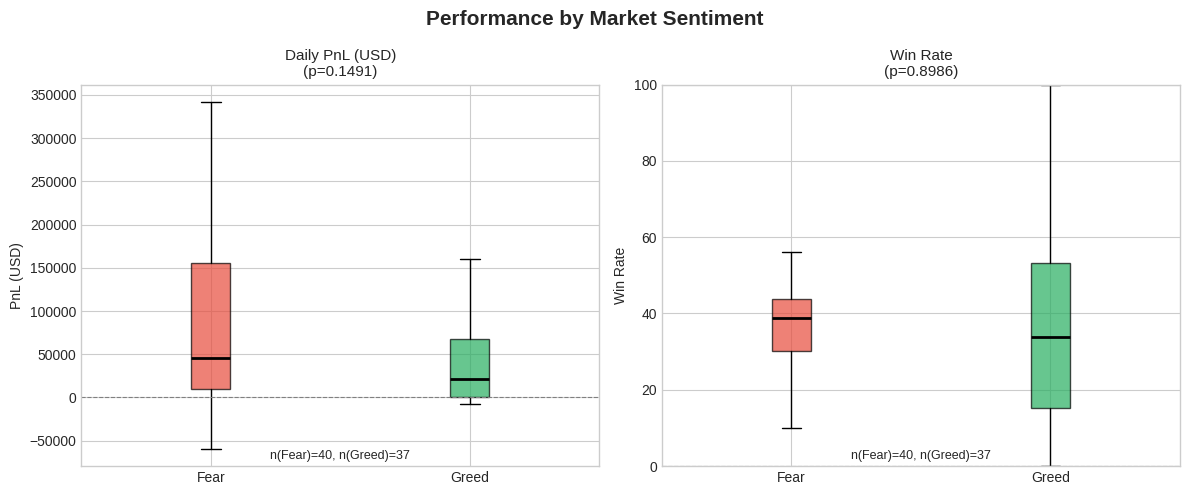

Saved fig1


In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Performance by Market Sentiment', fontsize=15, fontweight='bold')

for ax, col, title, ylabel in zip(
    axes,
    ['daily_pnl', 'win_rate'],
    ['Daily PnL (USD)', 'Win Rate'],
    ['PnL (USD)', 'Win Rate']
):
    fear_data  = merged.loc[merged['sentiment_binary'] == 'Fear',  col].dropna()
    greed_data = merged.loc[merged['sentiment_binary'] == 'Greed', col].dropna()

    # Convert win rate to %
    if col == 'win_rate':
        fear_data  = fear_data * 100
        greed_data = greed_data * 100
        ax.set_ylim(0, 100)

    bp = ax.boxplot(
        [fear_data, greed_data],
        labels=['Fear', 'Greed'],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        showfliers=False
    )
    for patch, color in zip(bp['boxes'], [COLORS['Fear'], COLORS['Greed']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    stat, pval = stats.mannwhitneyu(fear_data, greed_data, alternative='two-sided')
    ax.set_title(f'{title}\n(p={pval:.4f})', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

    ax.text(
        0.5, 0.02,
        f"n(Fear)={len(fear_data)}, n(Greed)={len(greed_data)}",
        transform=ax.transAxes,
        ha='center',
        fontsize=9
    )

plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/fig1_performance_by_sentiment.png', dpi=150)
plt.show()

print('Saved fig1')

In [ ]:
print("=== Statistical Significance (Mann–Whitney U) ===")
for col in ['daily_pnl', 'win_rate']:
    fear_data  = merged.loc[merged['sentiment_binary'] == 'Fear',  col].dropna()
    greed_data = merged.loc[merged['sentiment_binary'] == 'Greed', col].dropna()

    if col == 'win_rate':
        fear_data  = fear_data * 100
        greed_data = greed_data * 100

    stat, pval = stats.mannwhitneyu(fear_data, greed_data, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))

    effect = greed_data.median() - fear_data.median()

    print(
        f'{col:15s} | '
        f'Fear med={fear_data.median():.2f} | '
        f'Greed med={greed_data.median():.2f} | '
        f'Diff={effect:.2f} | '
        f'p={pval:.4f} {sig} | '
        f'n(Fear)={len(fear_data)}, n(Greed)={len(greed_data)}'
    )

=== Statistical Significance (Mann–Whitney U) ===
daily_pnl       | Fear med=46070.49 | Greed med=20925.51 | Diff=-25144.98 | p=0.1491 n.s. | n(Fear)=40, n(Greed)=37
win_rate        | Fear med=38.76 | Greed med=33.82 | Diff=-4.94 | p=0.8986 n.s. | n(Fear)=40, n(Greed)=37


### B2. Behavioral Changes by Sentiment

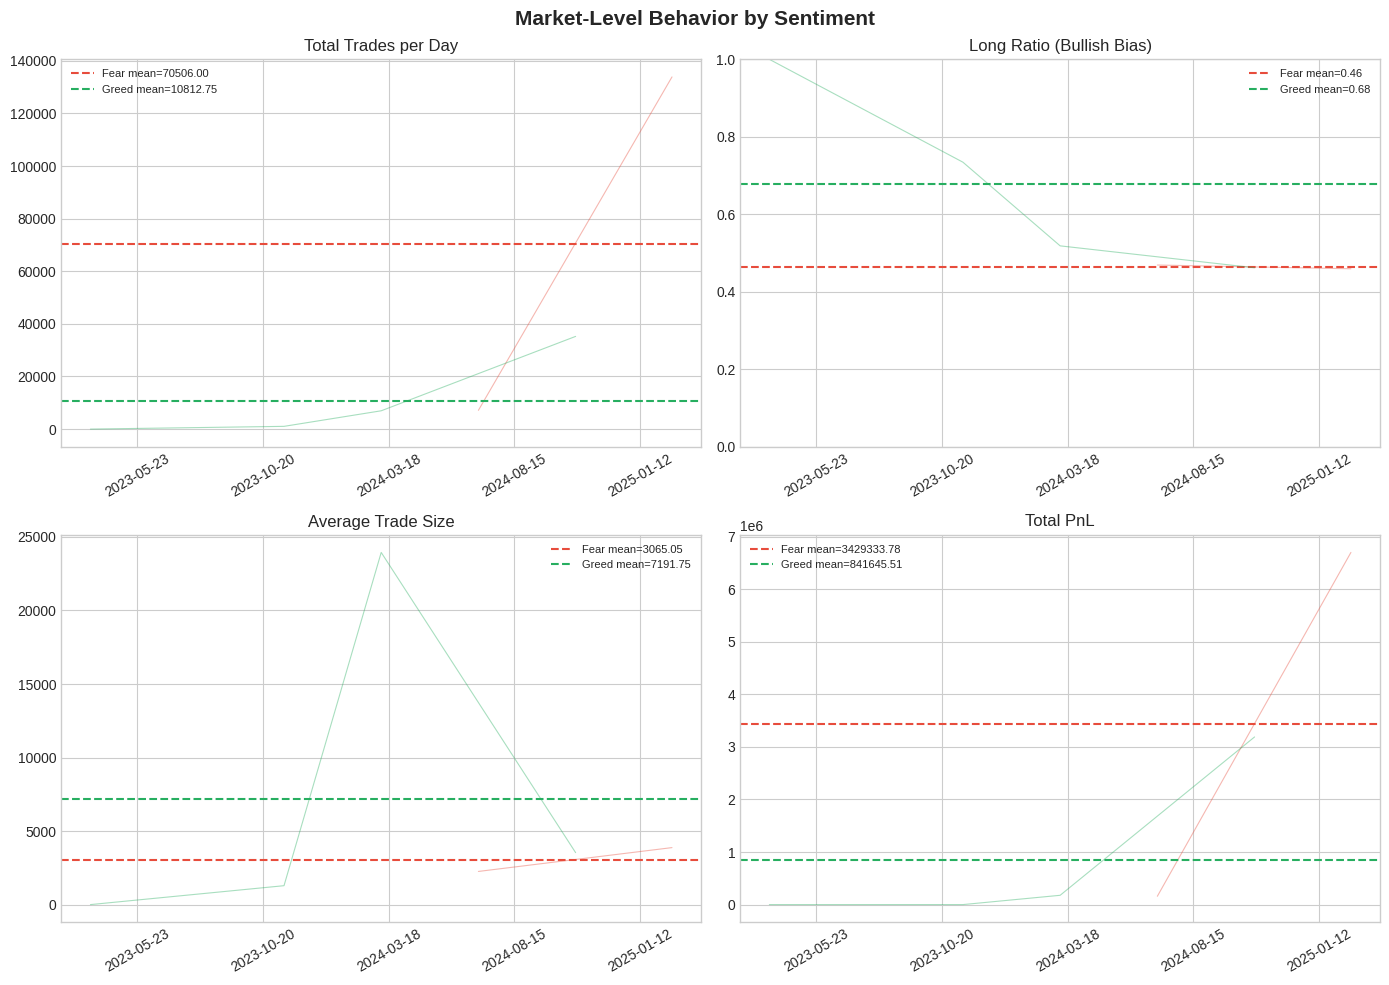

Saved fig2


In [ ]:
# ── Daily aggregate across all traders
daily_market = (
    merged
    .groupby(['date', 'sentiment_binary'])
    .agg(
        total_pnl      = ('daily_pnl', 'sum'),
        active_traders = (ACCOUNT_COL, 'nunique'),
        total_trades   = ('num_trades', 'sum'),
        long_ratio     = ('long_ratio', 'mean'),
        avg_size       = ('avg_size', 'mean')
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Market-Level Behavior by Sentiment', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(
    axes.flat,
    [('total_trades', 'Total Trades per Day'),
     ('long_ratio',   'Long Ratio (Bullish Bias)'),
     ('avg_size',     'Average Trade Size'),
     ('total_pnl',    'Total PnL')]
):
    for sentiment, color in COLORS.items():
        if sentiment == 'neutral':
            continue
        subset = daily_market[daily_market['sentiment_binary'] == sentiment]

        series = subset[col]
        ax.plot(subset['date'], series, color=color, alpha=0.4, linewidth=0.8)
        ax.axhline(series.mean(), color=color, linestyle='--', linewidth=1.5,
                   label=f'{sentiment} mean={series.mean():.2f}')

    if col == 'long_ratio':
        ax.set_ylim(0, 1)

    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/fig2_behavior_by_sentiment.png', dpi=150)
plt.show()

print('Saved fig2')

### B3. Trader Segmentation

In [ ]:
trader_profile = (
    merged
    .groupby(ACCOUNT_COL)
    .agg(
        total_pnl    = ('daily_pnl', 'sum'),
        avg_pnl      = ('daily_pnl', 'mean'),
        pnl_std      = ('daily_pnl', 'std'),
        total_trades = ('num_trades', 'sum'),
        avg_win_rate = ('win_rate', 'mean'),
        avg_size     = ('avg_size', 'mean'),
        active_days  = ('date', 'nunique')
    )
    .reset_index()
)

trader_profile['pnl_consistency'] = (
    trader_profile['avg_pnl'] / (trader_profile['pnl_std'] + 1e-9)
).clip(-10, 10)

trader_profile['trades_per_day'] = (
    trader_profile['total_trades'] / trader_profile['active_days']
)

trader_profile = trader_profile.merge(trader_drawdown, on=ACCOUNT_COL, how='left')

trader_profile['low_activity_flag'] = trader_profile['active_days'] < 5

print(trader_profile.describe())

           total_pnl      avg_pnl        pnl_std  total_trades  avg_win_rate  \
count        32.0000      32.0000        29.0000       32.0000       32.0000   
mean    319,539.0499 146,817.4442   170,500.2552    5,758.2188        0.3794   
std     463,277.2885 220,206.5782   308,644.0045    7,589.4027        0.1347   
min     -27,704.5674  -4,617.4279     2,481.0390      332.0000        0.1438   
25%      49,548.7287  23,833.7463    30,325.4728    1,113.2500        0.2555   
50%     120,756.6299  60,378.3150    66,863.9700    3,152.5000        0.4105   
75%     396,137.6727 175,627.9982   162,123.1835    7,694.2500        0.4771   
max   2,040,922.4260 940,157.2127 1,594,696.6428   36,534.0000        0.6525   

         avg_size  active_days  pnl_consistency  trades_per_day  max_drawdown  
count     32.0000      32.0000          29.0000         32.0000       32.0000  
mean   3,647.5641       2.4062           1.3366      2,965.4531  -22,664.9700  
std    8,271.6764       1.1031         

In [ ]:
# ── Segment 2: Frequent vs Infrequent Traders
freq_med = trader_profile['trades_per_day'].median()
trader_profile['freq_seg'] = np.where(
    trader_profile['trades_per_day'] >= freq_med,
    'Frequent',
    'Infrequent'
)

# ── Segment 3: Consistent Winners vs Others
cons_q75 = trader_profile['pnl_consistency'].quantile(0.75)

trader_profile['consistency_seg'] = pd.cut(
    trader_profile['pnl_consistency'],
    bins=[-np.inf, 0, cons_q75, np.inf],
    labels=['Losers', 'Inconsistent', 'Consistent Winners']
)

# Add 'Low Activity' to categories before assignment
current_categories = trader_profile['consistency_seg'].cat.categories.tolist()
new_categories = current_categories + ['Low Activity']
trader_profile['consistency_seg'] = trader_profile['consistency_seg'].cat.set_categories(new_categories)

# Flag low-activity traders
trader_profile.loc[
    trader_profile['low_activity_flag'],
    'consistency_seg'
] = 'Low Activity'

print(trader_profile[['freq_seg', 'consistency_seg']].value_counts())

freq_seg    consistency_seg
Frequent    Low Activity       15
Infrequent  Low Activity       15
Frequent    Inconsistent        1
Infrequent  Losers              1
Name: count, dtype: int64


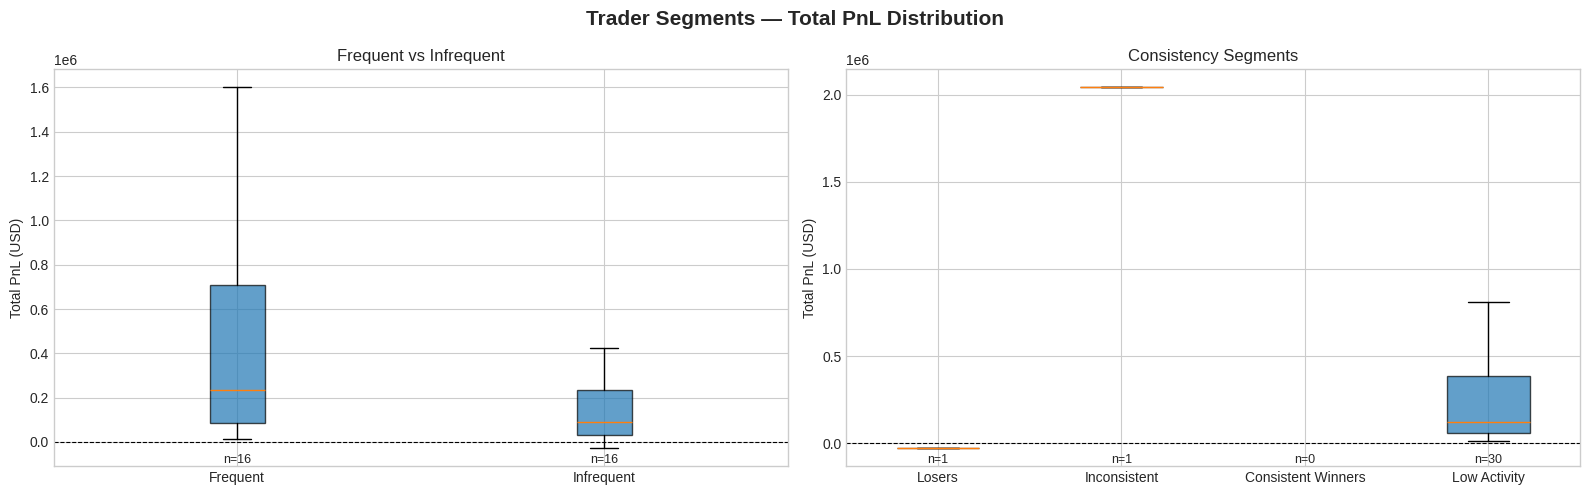

Saved fig3


In [ ]:
# ── Segment comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Trader Segments — Total PnL Distribution', fontsize=15, fontweight='bold')

for ax, (seg_col, title) in zip(
    axes,
    [('freq_seg', 'Frequent vs Infrequent'),
     ('consistency_seg', 'Consistency Segments')]
):
    groups = trader_profile.groupby(seg_col)['total_pnl'].apply(list)

    bp = ax.boxplot(
        groups.values,
        labels=groups.index,
        patch_artist=True,
        showfliers=False
    )

    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    ax.set_title(title)
    ax.set_ylabel('Total PnL (USD)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    for i, label in enumerate(groups.index):
        ax.text(
            i + 1, ax.get_ylim()[0],
            f"n={len(groups[label])}",
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig('charts/fig3_trader_segments.png', dpi=150)
plt.show()

print('Saved fig3')

Median daily PnL by Frequency × Sentiment:
freq_seg            Frequent  Infrequent
sentiment_binary                        
Fear             54,421.7699 37,927.2786
Greed            44,579.5464  8,695.3573

Sample sizes:
freq_seg          Frequent  Infrequent
sentiment_binary                      
Fear                    20          20
Greed                   18          19


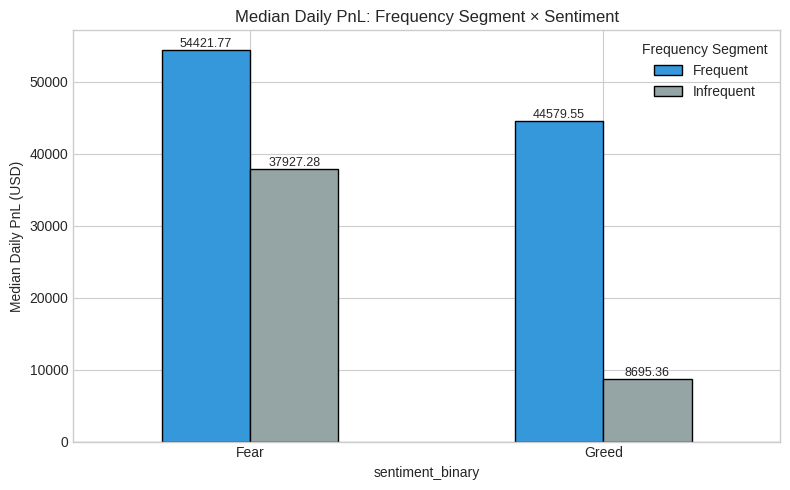

Saved fig4


In [ ]:
# ── Segment × Sentiment interaction
merged2 = merged.merge(
    trader_profile[[ACCOUNT_COL, 'freq_seg', 'consistency_seg']],
    on=ACCOUNT_COL, how='left'
)

pivot_freq_sent = (
    merged2
    .groupby(['sentiment_binary', 'freq_seg'])['daily_pnl']
    .median()
    .unstack()
)

print('Median daily PnL by Frequency × Sentiment:')
print(pivot_freq_sent)

print('\nSample sizes:')
print(
    merged2
    .groupby(['sentiment_binary', 'freq_seg'])
    .size()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_freq_sent.plot(
    kind='bar',
    ax=ax,
    color=['#3498DB', '#95A5A6'],
    edgecolor='black'
)

ax.set_title('Median Daily PnL: Frequency Segment × Sentiment', fontsize=12)
ax.set_ylabel('Median Daily PnL (USD)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title='Frequency Segment')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig('charts/fig4_frequency_sentiment_interaction.png', dpi=150)
plt.show()

print('Saved fig4')

### B4. Insight 3 — Cumulative PnL over time coloured by sentiment

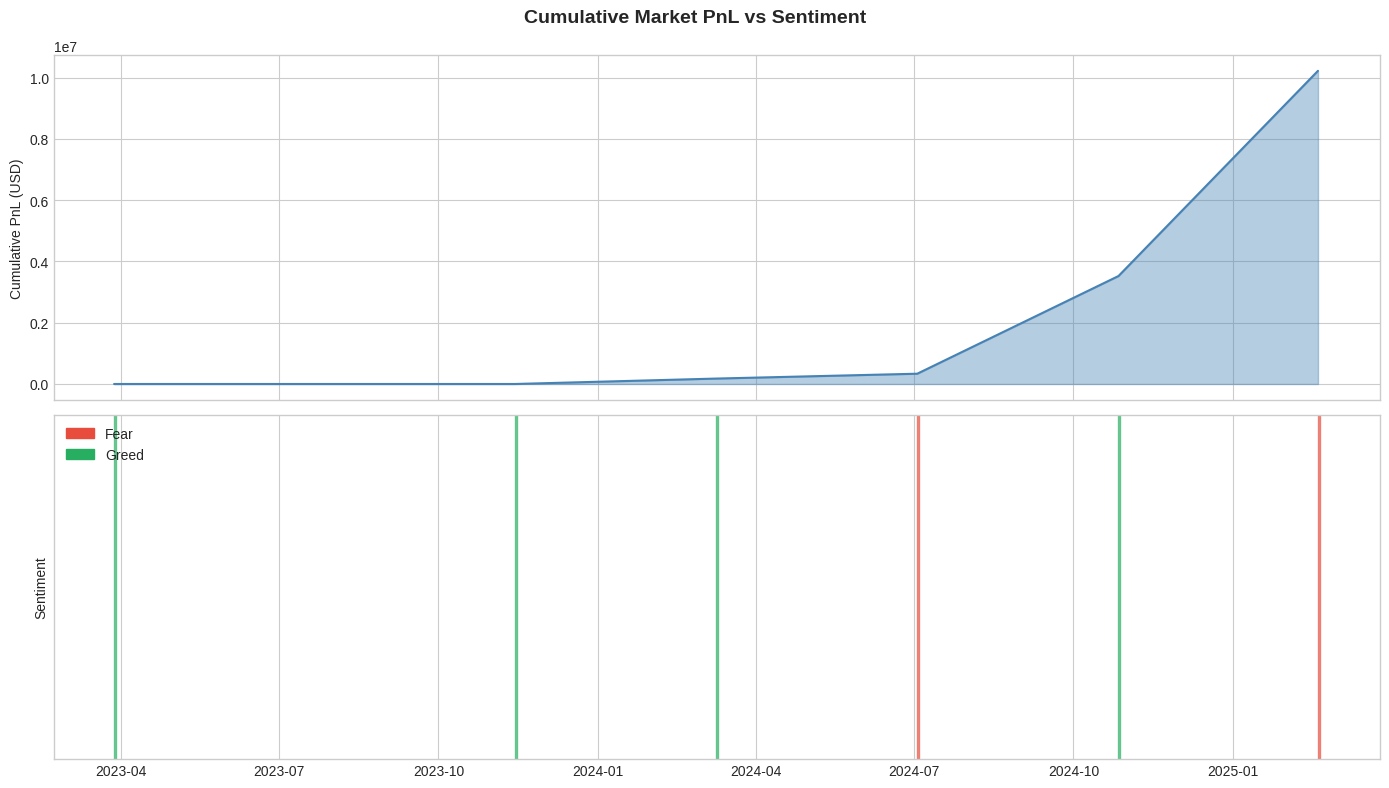

Saved fig5


In [ ]:
daily_agg = (
    merged
    .groupby(['date', 'sentiment_binary'])['daily_pnl']
    .sum()
    .reset_index()
    .sort_values('date')
)
daily_agg['cum_pnl'] = daily_agg['daily_pnl'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Cumulative Market PnL vs Sentiment', fontsize=14, fontweight='bold')

ax1.fill_between(daily_agg['date'], daily_agg['cum_pnl'], alpha=0.4, color='steelblue')
ax1.plot(daily_agg['date'], daily_agg['cum_pnl'], color='steelblue')
ax1.set_ylabel('Cumulative PnL (USD)')

for _, row in daily_agg.iterrows():
    ax2.axvspan(row['date'], row['date'] + pd.Timedelta(days=1),
                alpha=0.6, color=COLORS[row['sentiment_binary']])
ax2.set_ylabel('Sentiment')
ax2.set_yticks([])
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color=COLORS['Fear'], label='Fear'), Patch(color=COLORS['Greed'], label='Greed')],
           loc='upper left')

plt.tight_layout()
plt.savefig('charts/fig5_cumulative_pnl_sentiment.png', dpi=150)
plt.show()
print('Saved fig5')

---
##  Clustering & Predictive Model

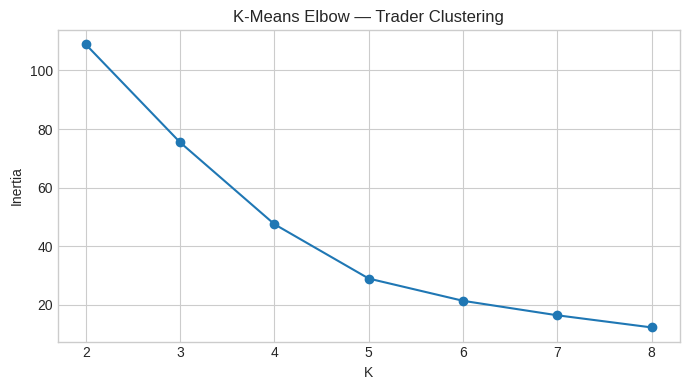


Cluster Sizes:
cluster
0     1
1    27
2     2
3     2
Name: count, dtype: int64

Cluster Profiles:
             avg_pnl        pnl_std  avg_win_rate  trades_per_day    avg_size
cluster                                                                      
0       800,114.9100 1,594,696.6430        0.2160      1,909.0000     14.4980
1        88,058.7580   112,946.5510        0.3640      1,839.7960  1,801.4570
2        87,354.0740    66,056.9150        0.5780      1,927.0000 33,879.1470
3       672,874.3510   394,033.1510        0.4720     19,728.5000    154.9610


In [ ]:
if SKLEARN_AVAILABLE:
    CLUSTER_FEATURES = ['avg_pnl', 'pnl_std', 'avg_win_rate',
                        'trades_per_day', 'avg_size']

    X_cluster = trader_profile[CLUSTER_FEATURES].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    # Elbow method
    inertias = []
    K_range = range(2, 9)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(list(K_range), inertias, 'o-')
    ax.set_xlabel('K')
    ax.set_ylabel('Inertia')
    ax.set_title('K-Means Elbow — Trader Clustering')
    plt.tight_layout()
    plt.savefig('charts/fig6_elbow.png', dpi=150)
    plt.show()

    # Fit final model
    km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
    trader_profile['cluster'] = km4.fit_predict(X_scaled)

    print('\nCluster Sizes:')
    print(trader_profile['cluster'].value_counts().sort_index())

    cluster_summary = trader_profile.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)
    print('\nCluster Profiles:')
    print(cluster_summary.to_string())
else:
    print('Skipping bonus — install scikit-learn: pip install scikit-learn')

Target distribution:
target
1   0.5195
0   0.4805
Name: proportion, dtype: float64
Next-Day Profitability Prediction — CV AUC: 0.868 ± 0.105


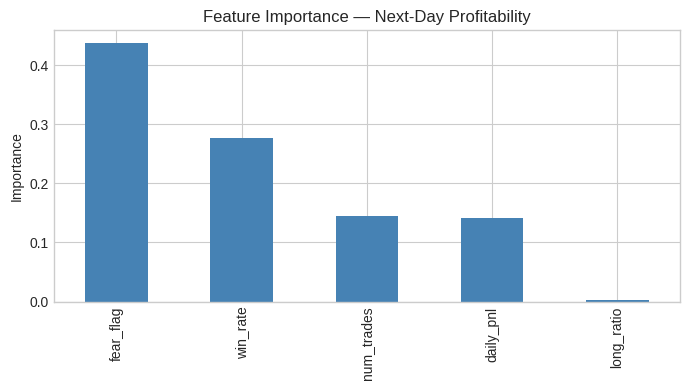

Saved fig7


In [ ]:
if SKLEARN_AVAILABLE:
    # ── Predict next-day profitability bucket
    merged2_sorted = merged2.sort_values(['account', 'date'])
    merged2_sorted['next_day_pnl'] = (
        merged2_sorted.groupby('account')['daily_pnl'].shift(-1)
    )
    merged2_sorted['target'] = (merged2_sorted['next_day_pnl'] > 0).astype(int)
    merged2_sorted = merged2_sorted.dropna(subset=['target'])

    FEAT_COLS = ['daily_pnl', 'win_rate', 'num_trades', 'long_ratio']
    merged2_sorted['fear_flag'] = (
        merged2_sorted['sentiment_binary'] == 'Fear'
    ).astype(int)

    FEAT_COLS_MODEL = FEAT_COLS + ['fear_flag']
    X = merged2_sorted[FEAT_COLS_MODEL].fillna(0)
    y = merged2_sorted['target']

    print("Target distribution:")
    print(y.value_counts(normalize=True))

    gb = GradientBoostingClassifier(
        n_estimators=100, max_depth=3, random_state=42
    )

    cv_scores = cross_val_score(gb, X, y, cv=5, scoring='roc_auc')
    print(
        f'Next-Day Profitability Prediction — '
        f'CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}'
    )

    gb.fit(X, y)
    feat_imp = (
        pd.Series(gb.feature_importances_, index=FEAT_COLS_MODEL)
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    feat_imp.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Feature Importance — Next-Day Profitability')
    ax.set_ylabel('Importance')
    plt.tight_layout()
    plt.savefig('charts/fig7_feature_importance.png', dpi=150)
    plt.show()

    print('Saved fig7')
else:
    print('Skipping predictive model — scikit-learn not available')

---
## Summary Table

In [ ]:
print('=== Final Dataset Sizes ===')
print(f'Sentiment records   : {len(sent)}')
print(f'Trade records       : {len(trades)}')
print(f'Merged observations : {len(merged)}')
print(f'Unique traders      : {merged[ACCOUNT_COL].nunique()}')
print(f'Date overlap        : {merged["date"].min().date()} → {merged["date"].max().date()}')

=== Final Dataset Sizes ===
Sentiment records   : 2644
Trade records       : 211224
Merged observations : 77
Unique traders      : 32
Date overlap        : 2023-03-28 → 2025-02-19
